# 01 — Data Audit & Role Mapping

This notebook explores and validates the raw job-posting data ingested into the pipeline.

The analysis focuses on:
- auditing the quality and structure of the collected job data
- inspecting duplicate and missing records
- normalizing multilingual and noisy job titles
- mapping raw titles to a canonical role taxonomy using rule-based matching strategies

The goal is to ensure the downstream extraction pipeline operates on clean, consistently categorized job postings.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('../src')))

In [2]:
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup

from config import config 

## 1. Data Audit

### Connection and Schema Overview
Quick sanity check of the raw tables and the main fields available for downstream processing.

In [3]:
with duckdb.connect(config.db_path) as con:
    print(con.execute("""
        SELECT schema_name, table_name, estimated_size
        FROM duckdb_tables()
    """).df())

  schema_name        table_name  estimated_size
0        main  descriptions_raw            2358
1        main          jobs_raw            2385


### Posting Volume Over Time
This helps verify temporal coverage and shows whether demand metrics can be built from the current data.

In [4]:
with duckdb.connect(config.db_path) as con:
    print(con.execute("""
        SELECT MIN(fetched_at)
        FROM jobs_raw
    """).fetchone()[0])

2026-03-19 19:40:02.303823


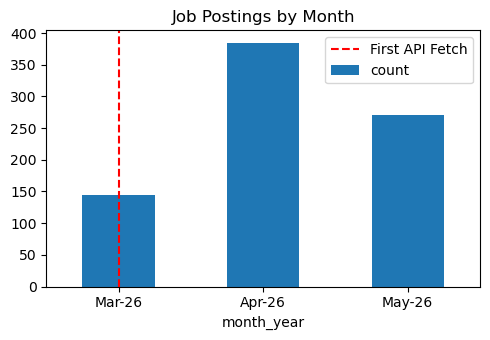

In [5]:
with duckdb.connect(config.db_path) as con:
    # Get earliest fetch and the chart data
    fetch_dt = con.execute("SELECT MIN(fetched_at) FROM jobs_raw").fetchone()[0]
    
    posting_freq = con.execute("""
        SELECT strftime(created_at, '%b-%y') as month_year, COUNT(*) as count
        FROM jobs_raw GROUP BY ALL ORDER BY min(created_at)
    """).df()

# Plot
ax = posting_freq.plot.bar(x="month_year", y="count", figsize=(5,3.5), rot=0, legend=False)

if fetch_dt:
    label = fetch_dt.strftime('%b-%y')
    if label in posting_freq['month_year'].values:
        idx = posting_freq[posting_freq['month_year'] == label].index[0]
        plt.axvline(x=idx, color='red', ls='--', label='First API Fetch')
        plt.legend()

plt.title("Job Postings by Month")
plt.tight_layout()
plt.show()

### Description Length Distribution
The description field is central to requirement extraction, so we check how much text is available and how noisy or truncated it looks.

In [6]:
def extract_plain_desc(desc_html):
    if desc_html is None:
        return ""
    soup = BeautifulSoup(desc_html, 'html.parser')
    return soup.get_text(strip=True)

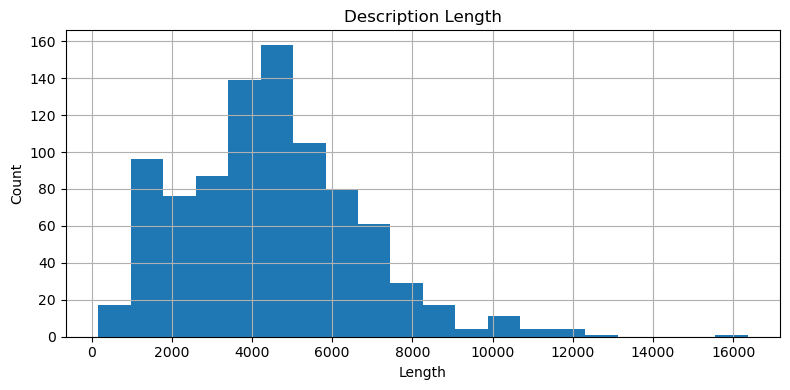

In [7]:
with duckdb.connect(config.db_path) as con:
    (con.execute("SELECT html_description FROM descriptions_raw")
        .df()["html_description"]
        .apply(extract_plain_desc)
        .str.len().round(2)
        .hist(bins=20, figsize=(8,4))
    )
    plt.title("Description Length")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.tight_layout()

## 2. Canonical Role Mapping
Map noisy job titles to a smaller set of canonical roles that can be used for aggregation, scoring, and search.

In [8]:
with duckdb.connect(config.db_path) as con:
    df = con.execute("""
        SELECT 
            p.source_job_id as job_id,
            p.raw_json->>'title' AS title,
            p.raw_json->'company'->>'display_name' AS comapany,
            p.raw_json->'location'->>'display_name' AS location,
            CAST(p.raw_json->>'salary_min' AS FLOAT) AS min_salary,
            CAST(p.raw_json->>'salary_max' AS FLOAT) AS max_salary,
            d.html_description,
            p.created_at AS posted,
            p.search_term as search_term
        FROM jobs_raw p
        JOIN descriptions_raw d
        ON p.source_job_id = d.source_job_id
    """).df()

In [9]:
df.head()

,job_id,title,comapany,location,min_salary,max_salary,html_description,posted,search_term
0,5682401255,Data Scientist,Canadian Tire Corporation,"Toronto, Ontario",NaN,NaN,"<p><b>What You’ll Do:</b></p><p style=""""></p><...",2026-03-29 16:23:35,data scientist
1,5680603425,"Data Scientist, Private Brand Analytics",Amazon,"Greater Vancouver, British Columbia",NaN,NaN,This role is on the Core Tech Private Brands A...,2026-03-27 16:33:29,data scientist
2,5681563887,AI/ML Engineer,The Vanguard Group,"Toronto, Ontario",NaN,NaN,We are looking for a Machine Learning Engineer...,2026-03-28 16:26:40,data scientist
3,5679503416,"Student Researcher, BS/MS, Winter/Summer 2026",Google,"Waterloo region, Ontario",NaN,NaN,<i>info_outline</i>X<p>Applications will be re...,2026-03-26 16:26:20,data scientist
4,5678375940,Senior AI/ML Research Engineer,The Vanguard Group,"Toronto, Ontario",NaN,NaN,Push the boundaries of AI innovation while con...,2026-03-25 16:21:27,data scientist


## Title normalization
Clean titles before matching so that bilingual formatting, punctuation, and title noise do not reduce mapping coverage.

In [10]:
df["matched_role"] = None
df["match_method"] = None

#### Normalize bilingual terms (french)

In [11]:
def normalize_french_terms(title):
    clean_title = re.sub(r"[éè]", "e", title)
    clean_title = re.sub(r" +ia +", "ai", clean_title)
    clean_title = re.sub(r"(·|\.)(euse|se|e)|\((\-?euse|se|e)\)", "", clean_title.lower())
    clean_title = re.sub(r"(ingenieur|ingenierie) logiciel", "software engineer", clean_title)
    clean_title = re.sub(r"(ingenieur|ingenierie|architecte)( de)? donnees", "data engineer", clean_title)
    clean_title = re.sub(r"(developpeur|developpement)( de)? logiciel", "software developer", clean_title)
    clean_title = re.sub(r"science des? donnees|scientifique des? donnees", "data scientist", clean_title)
    clean_title = re.sub(r"(des? )?donnees", "data", clean_title)
    clean_title = re.sub(r"developpeur|(^|\s+)Dev(\s+|$)", "developer", clean_title)
    clean_title = re.sub(r"ingenieur", "engineer", clean_title)
    clean_title = re.sub(r"(stagaire|stage)( +en)?", "internship", clean_title)
    return clean_title.strip()

In [12]:
df["cleaned_title"] = df["title"].apply(normalize_french_terms)

### Remove seniority signals

In [13]:
def remove_seniority(title):
    pattern = re.compile(r"\b(senior|sr\.?|staff|intermediate|associate|junior|jr\.?|internship|intern|new grad(uate)?|rotational program)( |,|\)|$)?\b")
    clean_title = pattern.sub("", title)
    clean_title = re.sub("^[^a-zA-Z]+", "", clean_title)
    return clean_title.strip()

In [14]:
df["cleaned_title"] = df["cleaned_title"].apply(remove_seniority)

### Normalize common terms

In [15]:
def normalize_common_terms(title):
    clean_title = re.sub(r"prompt engineer", "ai developer", title)
    clean_title = re.sub(r"software development|software dev ", "software developer", clean_title)
    clean_title = re.sub(r"swe ", "software engineer ", clean_title)
    clean_title = re.sub(r"ai/ml|artificial intelligence", "ai", clean_title)
    clean_title = re.sub(r"swe ", "software engineer ", clean_title)
    clean_title = re.sub(r"(python|c#(/\.net)?|net|javascript|typescript|(c/)?c\+\+|react|node\.?js?|java|typescript|c(-| )sharp) developer", "software developer", clean_title)
    clean_title = re.sub(r"engineering|engineers", "engineer", clean_title)
    clean_title = re.sub(r"development|developers", "developer", clean_title)
    return clean_title

In [16]:
df["cleaned_title"] = df["cleaned_title"].apply(normalize_common_terms)

### Alias and rule-based matching
Try lightweight matching first. The goal is high coverage with interpretable rules, not perfect classification.

#### Exact match

In [17]:
def compile_taxonomy(taxonomy):
    compiled_data = []
    for role in taxonomy:
        pattern_str = r"(?i)\b(" + "|".join([re.escape(a) for a in role["aliases"]]) + r")\b"
        compiled_data.append({
            "name": role["name"],
            "pattern": re.compile(pattern_str)
        })
    return compiled_data

COMPILED_TAXONOMY = compile_taxonomy(config.role_taxonomy)

In [18]:
def match_aliases(title):
    result = {"matched_role": None, "match_method": None}
    
    if not title:
        return pd.Series(result)
    
    for role in COMPILED_TAXONOMY:
        if role["pattern"].search(title):
            return pd.Series({
                "matched_role": role["name"],
                "match_method": "exact_match"
            })
    
    return pd.Series(result)

In [19]:
df[["matched_role", "match_method"]] = df["cleaned_title"].apply(match_aliases)

#### Flexible match

In [20]:
def match_sets(title):
    result = {"matched_role": None, "match_method": None}

    if not title:
        return pd.Series(result)
    
    # Normalize title into a set of words
    title_words = set(re.findall(r'\w+', title.lower()))
    
    for role in config.role_taxonomy:
        for alias in role["aliases"]:
            alias_words = set(alias.lower().split())
            #if len(alias_words) > 3:
            #    continue
            # Check if all words in the alias exist in the title
            if alias_words.issubset(title_words):
                return pd.Series({
                    "matched_role": role["name"],
                    "match_method": "flexible_match"
                })
    
    return pd.Series(result)

In [21]:
mask = df["matched_role"].isnull()
df.loc[mask, ["matched_role", "match_method"]] = df.loc[mask, "cleaned_title"].apply(match_sets)

#### Keywords matching

In [22]:
def match_keywords(title):
    match_method = "keywords"
    ai_pattern = re.compile(r"(^|\s+|\(|/)(ai|agentic|gen(erative|\s+)ai)(\s+|$)")
    ml_pattern = re.compile(r"(^|\s+|\(|/)(ml|machine learning|nlp|computer vision|deep learning)(\s+|$)")
    data_eng_pattern = re.compile(r"(^|\s+|\(|/)(databricks|snowflake|data architect|etl)(\s+|$)")

    if ai_pattern.search(title):
        matched_role = "ai developer"
    elif ml_pattern.search(title):
        matched_role = "ml engineer"
    elif data_eng_pattern.search(title):
        matched_role = "data engineer"
    else:
        matched_role = None
        match_method = None
    return pd.Series({
        "matched_role": matched_role,
        "match_method": match_method
    })

In [23]:
mask = df["matched_role"].isnull()
df.loc[mask, ["matched_role", "match_method"]] = df.loc[mask, "cleaned_title"].apply(match_keywords)

#### Default

In [24]:
mask = df["matched_role"].isnull()
df.loc[mask, "match_method"] = "_FAILED_"

### Review unmatched titles
Inspect failures to decide whether to improve normalization rules, extend aliases, or expand the taxonomy.

In [25]:
failed = df[df['match_method'] == '_FAILED_'].copy()
print(f"~{len(failed)} ({100*len(failed)/len(df):.2f}%) of job titles could not be mapped to a canonical role")

~493 (65.56%) of job titles could not be mapped to a canonical role


In [26]:
failed["title"].sample(n=20, random_state=42).tolist()

['Python Developer',
 'Quality Assurance Intern',
 'Software Developer - Intermediate',
 'Backend Engineer',
 'Java Backend Developer',
 'Senior System Programmer - Unannounced IP | Programmeur·euse système Sénior·e - Projet non annoncé',
 'Spécialiste Salesforce',
 'Full Stack Developer (.NET / C# / SQL)',
 'Data Center Technician - CA - Waterloo - On-site',
 'Information Security Intern',
 'Senior Software Engineer',
 'Software Developer (C/C++)',
 'Quality Assurance Engineer',
 'Cracked Forward Deployed Engineer - Special Projects',
 'Technical Support Engineer',
 'Développeur·se logiciel',
 'Data Center Technician - Canada - Winnipeg - On-site',
 'Senior Full Stack Developer',
 'Senior TypeScript Engineer',
 'Staff Engineer']

In [27]:
mapped = df[df['match_method'] != '_FAILED_'].copy()

In [28]:
mapped["month_year"] = mapped["posted"].dt.to_period('M')
mapped["month_year"].value_counts().sort_index()

month_year
2026-03     69
2026-04    139
2026-05     51
Freq: M, Name: count, dtype: int64